# 언더피팅 vs 오버피팅 시각화

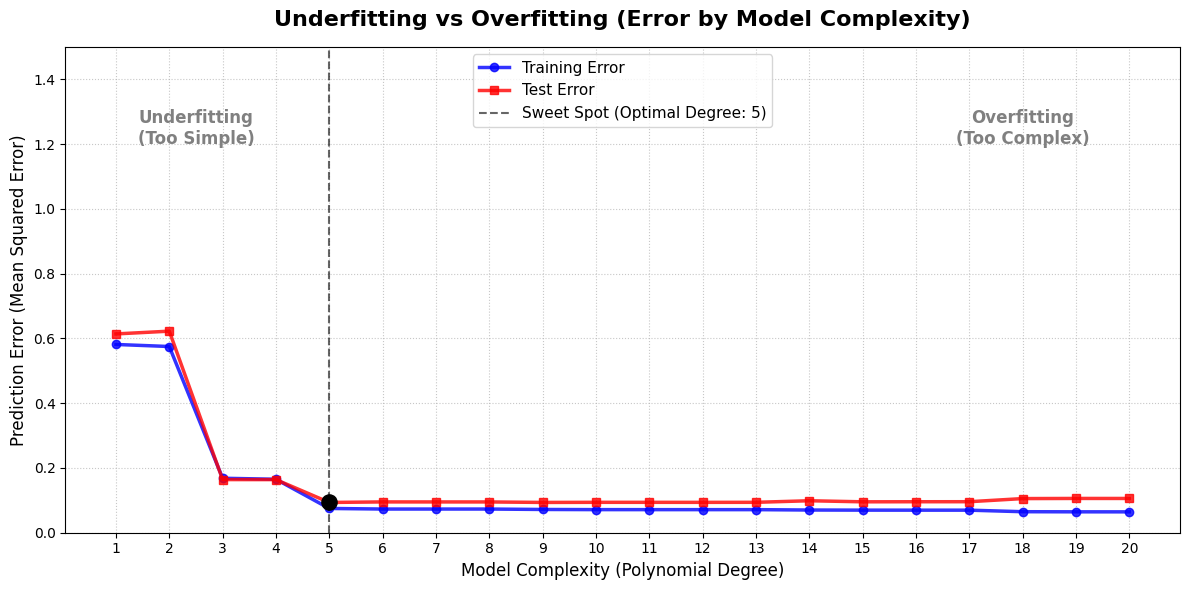

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# 1. 가상의 복잡한 비선형 데이터 생성
np.random.seed(42)

# ★ 핵심: X 범위를 0~1로 제한하여 고차항(X^20 등) 계산 시 수치 폭발 방지
n_samples = 200
X = np.sort(np.random.rand(n_samples, 1), axis=0)

# 구불구불한 코사인 곡선 (1~3차 단순 모델로는 절대 못 맞춤 -> 초기 높은 오차 유도)
y = np.cos(3 * np.pi * X).ravel() + np.random.randn(n_samples) * 0.3

# 훈련셋(50%)과 테스트셋(50%) 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 2. 다항식 차수(모델 복잡도)를 1차부터 20차까지 늘려가며 오차 기록
degrees = np.arange(1, 21)
train_errors = []
test_errors = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# 3. 언더피팅 vs 오버피팅 그래프 그리기
plt.figure(figsize=(12, 6))

# 파란색 선: 훈련 오류 (점점 줄어들어 바닥에 근접)
plt.plot(degrees, train_errors, 'b-o', label='Training Error', linewidth=2.5, alpha=0.8)

# 빨간색 선: 테스트 오류 (초반엔 같이 줄다가 나중에 치솟는 U자 형태)
plt.plot(degrees, test_errors, 'r-s', label='Test Error', linewidth=2.5, alpha=0.8)

# 최적점(Sweet Spot) 찾기
optimal_degree = degrees[np.argmin(test_errors)]
min_test_error = np.min(test_errors)

plt.axvline(x=optimal_degree, color='k', linestyle='--', alpha=0.6, label=f'Sweet Spot (Optimal Degree: {optimal_degree})')
plt.scatter(optimal_degree, min_test_error, color='black', s=120, zorder=5) 

# 영역별 텍스트 설명
plt.text(2.5, 1.2, 'Underfitting\n(Too Simple)', fontsize=12, ha='center', color='gray', fontweight='bold')
plt.text(18, 1.2, 'Overfitting\n(Too Complex)', fontsize=12, ha='center', color='gray', fontweight='bold')

plt.title('Underfitting vs Overfitting (Error by Model Complexity)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Prediction Error (Mean Squared Error)', fontsize=12)

# ★ Y축을 적절히 잘라서 초반의 높은 오차와 후반의 오버피팅 폭발을 완벽히 보여줌
plt.ylim(0, 1.5) 
plt.xticks(degrees)
plt.legend(fontsize=11, loc='upper center')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# 자동차 데이터 교차검증 구현 (Python / Scikit-learn)
선형 회귀 모델을 기준으로 '단순 검증셋', 'LOOCV', 'K-겹 CV'를 구현

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, LeaveOneOut, KFold, cross_val_score
from sklearn.metrics import mean_squared_error

# 가상의 자동차 데이터 생성 (X: 마력 등 특성, y: 연비 Label)
# 실제로는 pandas를 이용해 csv 파일을 불러옵니다.
np.random.seed(42)
X = np.random.rand(392, 1) * 150 + 50  # 마력 데이터 (50 ~ 200)
y = 50 - 0.2 * X.flatten() + np.random.randn(392) * 4  # 연비 데이터 (가상의 관계)

model = LinearRegression()

# ---------------------------------------------------------
# 1. 단순 검증셋 (Hold-out Validation)
# ---------------------------------------------------------
# 전체 데이터를 50:50으로 무작위 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=42)

model.fit(X_train, y_train)           # 훈련셋으로 학습
y_pred = model.predict(X_val)         # 검증셋으로 예측
mse_holdout = mean_squared_error(y_val, y_pred)

print(f"1. 단순 검증셋 MSE: {mse_holdout:.2f}")


# ---------------------------------------------------------
# 2. Leave-One-Out 교차검증 (LOOCV)
# ---------------------------------------------------------
loo = LeaveOneOut()
# cross_val_score를 사용하면 내부적으로 n번 분할하여 평가를 진행합니다.
scores_loo = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=loo)
mse_loo = -scores_loo.mean() # 사이킷런은 음수로 출력하므로 -를 붙여 양수로 전환

print(f"2. LOOCV MSE: {mse_loo:.2f} (총 {len(X)}번 모델 학습)")


# ---------------------------------------------------------
# 3. 10-겹 교차검증 (10-Fold Cross-Validation)
# ---------------------------------------------------------
# K=10으로 설정, 데이터를 섞어서(shuffle=True) 10등분
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores_kfold = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kfold)
mse_kfold = -scores_kfold.mean()

print(f"3. 10-겹 CV MSE: {mse_kfold:.2f} (총 10번 모델 학습)")

1. 단순 검증셋 MSE: 19.19
2. LOOCV MSE: 15.92 (총 392번 모델 학습)
3. 10-겹 CV MSE: 15.98 (총 10번 모델 학습)


# 검증셋 vs 10-겹 교차검증 시각화

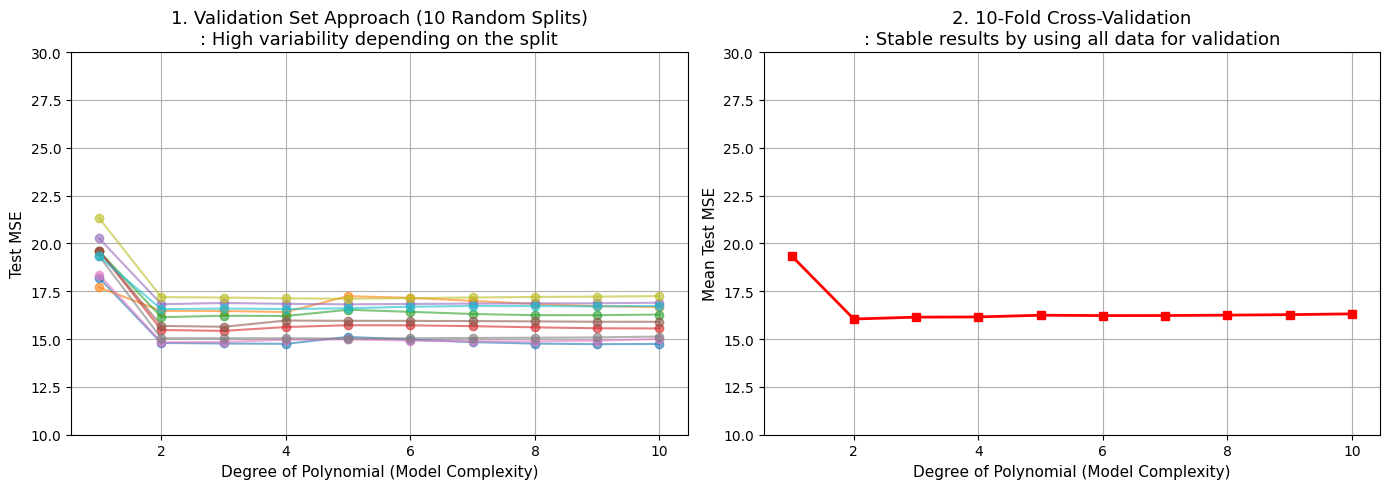

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# 1. 가상의 자동차 데이터 생성 (비선형성을 띄도록 2차 곡선 형태로 만듦)
np.random.seed(42)
X = np.random.rand(392, 1) * 150 + 50  # 마력 데이터
y = 50 - 0.2 * X.flatten() + 0.001 * (X.flatten()**2) + np.random.randn(392) * 4  # 연비

# 1차항(직선)부터 10차항(복잡한 곡선)까지 모델 복잡도를 늘려가며 테스트
degrees = np.arange(1, 11) 

# 시각화 캔버스 준비 (좌/우 2개의 그래프)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# [좌측 패널] 단순 검증셋 (Hold-out): 무작위 분할을 10번 반복
# ---------------------------------------------------------
for i in range(10): 
    # random_state를 0~9로 바꾸며 데이터를 10번 다르게 반반 나눔
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=i)
    
    mse_list = []
    for d in degrees:
        # 데이터를 d차항 다항식 특성으로 변환 (예: x -> x, x^2, x^3...)
        poly = PolynomialFeatures(degree=d)
        X_train_poly = poly.fit_transform(X_train)
        X_val_poly = poly.transform(X_val)
        
        # 모델 학습 및 예측
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_val_poly)
        
        # MSE 계산 후 저장
        mse_list.append(mean_squared_error(y_val, y_pred))
        
    # 각 분할마다 선 그래프 그리기
    axes[0].plot(degrees, mse_list, marker='o', alpha=0.6, label=f'Split {i+1}' if i < 3 else "")

axes[0].set_title("1. Validation Set Approach (10 Random Splits)\n: High variability depending on the split", fontsize=13)
axes[0].set_xlabel("Degree of Polynomial (Model Complexity)", fontsize=11)
axes[0].set_ylabel("Test MSE", fontsize=11)
axes[0].set_ylim(10, 30)
axes[0].grid(True)

# ---------------------------------------------------------
# [우측 패널] 10-겹 교차검증 (10-Fold CV)
# ---------------------------------------------------------
cv_mse_list = []
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # 10번 교차검증을 수행하고 MSE의 평균을 구함
    scores = cross_val_score(model, X_poly, y, scoring='neg_mean_squared_error', cv=kfold)
    cv_mse_list.append(-scores.mean())

# 안정적인 하나의 선 그래프 그리기
axes[1].plot(degrees, cv_mse_list, marker='s', color='red', linewidth=2)
axes[1].set_title("2. 10-Fold Cross-Validation\n: Stable results by using all data for validation", fontsize=13)
axes[1].set_xlabel("Degree of Polynomial (Model Complexity)", fontsize=11)
axes[1].set_ylabel("Mean Test MSE", fontsize=11)
axes[1].set_ylim(10, 30)
axes[1].grid(True)

plt.tight_layout()
plt.show()